<a href="https://colab.research.google.com/github/johanndeboda/AAI2026/blob/2026fall/ML/forecasting_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

54 months of sales, 2006-2010
Trend-only model  ->  R-squared: 0.003
Trend + season    ->  R-squared: 0.906


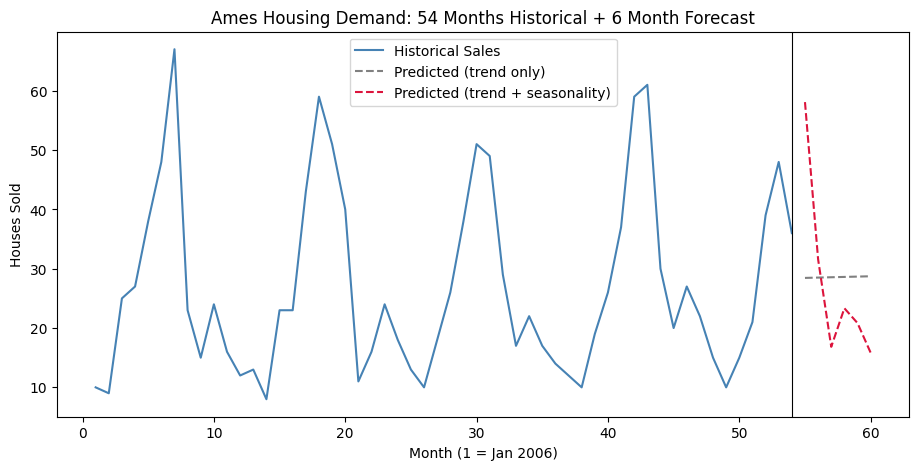

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Load dataset
url = 'https://raw.githubusercontent.com/johanndeboda/AAI2026/refs/heads/2026fall/ML/house_price.csv'
raw = pd.read_csv(url)

# Demand = number of houses sold per month
df = raw.groupby(['YrSold', 'MoSold']).size().reset_index(name='sales')

# July 2010 is a partial month (data collection stopped mid-month) - drop it
df = df[~((df['YrSold'] == 2010) & (df['MoSold'] == 7))].reset_index(drop=True)

# Sequential month index: 1 = Jan 2006
df['month'] = range(1, len(df) + 1)

print(f"{len(df)} months of sales, {df['YrSold'].min()}-{df['YrSold'].max()}")

X = df[['month']]
y = df['sales']

# Train the model
model = LinearRegression()
model.fit(X, y)
print(f"Trend-only model  ->  R-squared: {r2_score(y, model.predict(X)):.3f}")

# Predict for next 6 months
future_months = pd.DataFrame({'month': range(max(df['month'])+1, max(df['month'])+7)})
predictions = model.predict(future_months)

# Improvement: add month-of-year dummies to capture seasonality
X_seasonal = pd.get_dummies(df['MoSold'], prefix='mo', drop_first=True).astype(int)
X_seasonal.insert(0, 'month', df['month'])

seasonal_model = LinearRegression()
seasonal_model.fit(X_seasonal, y)
print(f"Trend + season    ->  R-squared: {r2_score(y, seasonal_model.predict(X_seasonal)):.3f}")

# Build the same dummy columns for the 6 future months
future_mo = [(df['MoSold'].iloc[-1] + i - 1) % 12 + 1 for i in range(1, 7)]
future_seasonal = pd.get_dummies(pd.Series(future_mo), prefix='mo').astype(int)
future_seasonal = future_seasonal.reindex(columns=X_seasonal.columns[1:], fill_value=0)
future_seasonal.insert(0, 'month', future_months['month'].values)

seasonal_predictions = seasonal_model.predict(future_seasonal)

# Plot results
plt.figure(figsize=(11, 5))
plt.plot(df['month'], y, label='Historical Sales', color='steelblue')
plt.plot(future_months['month'], predictions,
         label='Predicted (trend only)', linestyle='--', color='gray')
plt.plot(future_months['month'], seasonal_predictions,
         label='Predicted (trend + seasonality)', linestyle='--', color='crimson')
plt.axvline(x=max(df['month']), color='black', linewidth=0.8)
plt.xlabel('Month (1 = Jan 2006)')
plt.ylabel('Houses Sold')
plt.title('Ames Housing Demand: 54 Months Historical + 6 Month Forecast')
plt.legend()
plt.savefig('forecast.png', dpi=100, bbox_inches='tight')
plt.show()

## Assumptions
I used the Ames sales records capturing houses sold and based on this, given that the dataset spans back more than 10 years, it will give the ML model a considerable amount of information for it to be able to predict seasonal trends effectively should there be any trends regarding so. For this I looked into houses sold and the corresponding month(s)
## Challenges
The main challenege with this is that housing demand is seasonal and a very basic model would take the average and just draw a relatively straight line across the middle should it capture the entire picture at once like a basic linear model.
## Potential Improvements
To improve the model, I can implement a self-validating loop where it takes 12 months, makes inferences, then tests it as to what actually happened on a year by year basis rather than capturing the entire dataset in one split then making the inference.